In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/besansrewah/project/Book1.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)


In [3]:
data=pd.read_csv("/kaggle/input/datasets/besansrewah/project/Book1.csv")
print("\nFirst 5 rows:")
print(data.head())


First 5 rows:
   post_id   platform post_type        post_time  likes  comments  shares  \
0        1   Facebook     image  8/17/2023 14:45   2121       474     628   
1        2   Facebook  carousel   5/14/2023 0:45   3660       432     694   
2        3  Instagram      poll  2/21/2023 16:15   4955       408     688   
3        4    Twitter     image  11/16/2023 0:45   1183        90     187   
4        5    Twitter     video   5/23/2023 0:30   3499       247     286   

   post_day sentiment_score  
0  Thursday        positive  
1    Sunday         neutral  
2   Tuesday        negative  
3  Thursday        negative  
4   Tuesday        positive  


In [4]:
print("\nColumn Types:")
print(data.dtypes)


Column Types:
post_id             int64
platform           object
post_type          object
post_time          object
likes               int64
comments            int64
shares              int64
post_day           object
sentiment_score    object
dtype: object


In [5]:
# EDA
print(data.isnull().sum())


post_id            0
platform           0
post_type          0
post_time          0
likes              0
comments           0
shares             0
post_day           0
sentiment_score    0
dtype: int64


In [6]:
print("\n--- Target Distribution (sentiment_score) ---")
print(data['sentiment_score'].value_counts())


--- Target Distribution (sentiment_score) ---
sentiment_score
positive    57
neutral     32
negative    31
Name: count, dtype: int64


In [7]:
print("\n--- Numerical Stats ---")
print(data[['likes', 'comments', 'shares']].describe().round(0))


--- Numerical Stats ---
        likes  comments  shares
count   120.0     120.0   120.0
mean   2482.0     213.0   441.0
std    1586.0     140.0   283.0
min      15.0      10.0    16.0
25%    1167.0      99.0   203.0
50%    2305.0     182.0   407.0
75%    3680.0     314.0   725.0
max    5000.0     500.0   993.0


In [8]:
#preprocessing
df_clean = data.drop(columns=['post_id', 'post_time'])
print(df_clean.head())

    platform post_type  likes  comments  shares  post_day sentiment_score
0   Facebook     image   2121       474     628  Thursday        positive
1   Facebook  carousel   3660       432     694    Sunday         neutral
2  Instagram      poll   4955       408     688   Tuesday        negative
3    Twitter     image   1183        90     187  Thursday        negative
4    Twitter     video   3499       247     286   Tuesday        positive


In [9]:
# Encode categorical features
#convert from categorical to numerical
le_platform  = LabelEncoder()
le_type      = LabelEncoder()
le_day       = LabelEncoder()
le_sentiment = LabelEncoder()

df_clean['platform']  = le_platform.fit_transform(df_clean['platform'])
df_clean['post_type'] = le_type.fit_transform(df_clean['post_type'])
df_clean['post_day']  = le_day.fit_transform(df_clean['post_day'])


In [10]:
# Target
df_clean['sentiment_score'] = le_sentiment.fit_transform(df_clean['sentiment_score'])
print("Sentiment classes:", list(le_sentiment.classes_))

# Features and Target
X = df_clean.drop(columns=['sentiment_score'])
y = df_clean['sentiment_score']


Sentiment classes: ['negative', 'neutral', 'positive']


In [11]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [13]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(X_test_sc)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [14]:
# evaluation
target_names = [str(c) for c in le_sentiment.classes_]

# Logistic Regression
acc  = accuracy_score(y_test, lr_pred)
prec = precision_score(y_test, lr_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, lr_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, lr_pred, average='weighted', zero_division=0)
print("Logistic Regression")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")


# Random Forest
acc  = accuracy_score(y_test, rf_pred)
prec = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, rf_pred, average='weighted', zero_division=0)
print("Random Forest")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")


Logistic Regression
  Accuracy  : 0.4583
  Precision : 0.4375
  Recall    : 0.4583
  F1-Score  : 0.4357
Random Forest
  Accuracy  : 0.4167
  Precision : 0.4048
  Recall    : 0.4167
  F1-Score  : 0.4017


[Saved] ml_results.png


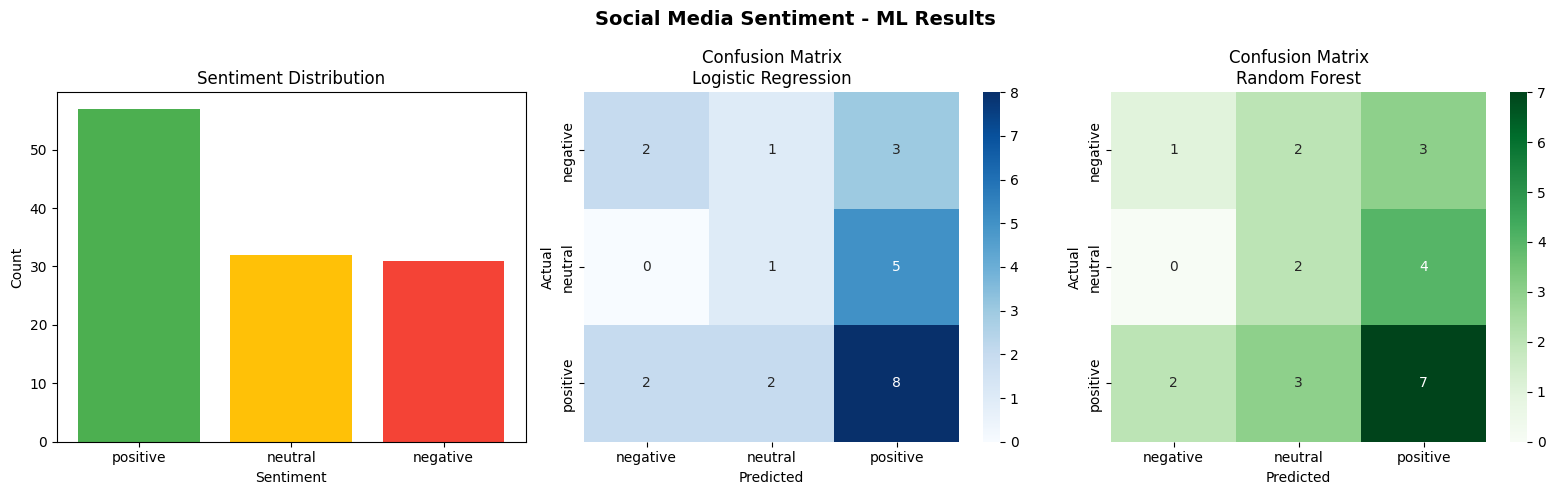

In [15]:
#visualization
# ============================================================
# 6. VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Social Media Sentiment - ML Results", fontsize=14, fontweight='bold')

# --- Plot 1: Sentiment Distribution ---
ax = axes[0]
counts = data['sentiment_score'].value_counts()
ax.bar(counts.index, counts.values, color=['#4CAF50', '#FFC107', '#F44336'])
ax.set_title("Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")


# --- Plot 2: Confusion Matrix - LR ---
ax = axes[1]
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
ax.set_title("Confusion Matrix\nLogistic Regression")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# --- Plot 3: Confusion Matrix - RF ---
ax = axes[2]
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
ax.set_title("Confusion Matrix\nRandom Forest")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("ml_results.png", dpi=150, bbox_inches='tight')
print("[Saved] ml_results.png")
